/home/ebertp/work/projects/chrom-y-extended
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/seqclass_stats
codebase/plotting/notebooks/seqclass_stats/y-seqclass-boxplot.ipynb


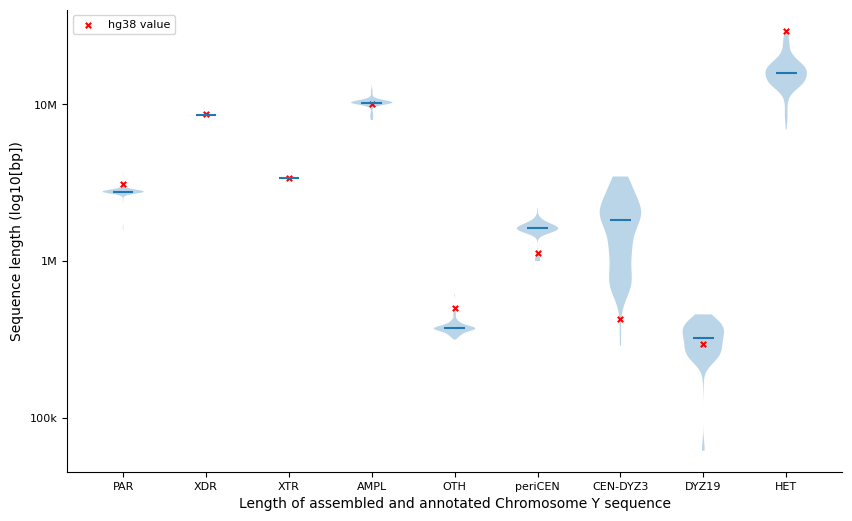

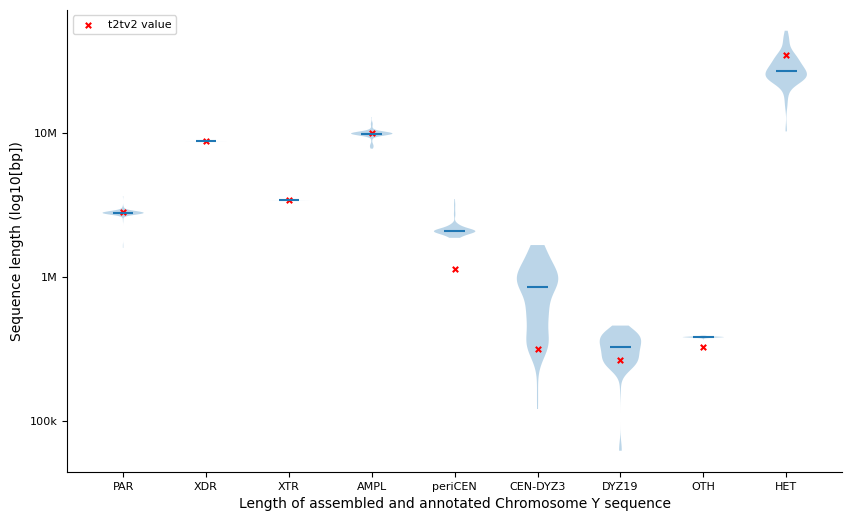

In [13]:
import pathlib as pl

# adapt relative path until it loads
cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
TABLE_ROOT = CONFIG["table_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

print(DATA_ROOT)
print(PLOT_ROOT)
print(NB_REL_PATH)

### NB-specific code

import collections as col
import re
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

PAPER_CONTENT = False
if PAPER_CONTENT:
    print("=== source")
    print(NB_REL_PATH)
    print("===")

LABEL_DATA_ROOT = DATA_ROOT.joinpath("wf-data/region-labels/final_annot/2026-02_final-rev")
UMBRELLA_DATA_ROOT = DATA_ROOT.joinpath("wf-data/region-labels/umbrellas")

ref_files = {
    "hg38": CONFIG["project_repo"].joinpath("annotation", "norm", "GRCh38-Y_regions_repeat-details.bed"),
    "t2tv2": CONFIG["project_repo"].joinpath("annotation", "norm", "HG002-Y_T2Tv2_regions_repeat-details.bed")
}

refs = list(ref_files.keys())
issue_labels = ["NGAP", "UNASSIGNED", "ERRSTRUCT", "ERRBASE"]


def load_label_order(ref):
    
    ref_regions_file = ref_files[ref]
    ref_regions = pd.read_csv(ref_regions_file, sep="\t", header=0)
    
    label_map_file = list(UMBRELLA_DATA_ROOT.joinpath(ref).glob(f"{ref}*.json"))[0]
    label_map = json.load(open(label_map_file))

    ref_regions["group"] = ref_regions["name"].apply(lambda n: label_map.get(n, {"group": "subregion"})["group"])
    ref_regions["length"] = ref_regions["end"] - ref_regions["start"]
    group_sizes = ref_regions.groupby("group")["length"].sum().to_dict()
    group_sizes["total"] = sum(v for k,v in group_sizes.items() if k != "subregion")
    
    order = []
    seen = set()
    pos = 0
    for k in sorted(label_map.keys()):
        label_info = label_map[k]
        if label_info["group"] in seen:
            continue
        seen.add(label_info["group"])
        pos += 1
        order.append((pos, label_info["group"]))
    assert pos == len(order)
    return order, group_sizes


def assign_seq_type(seqname):
    seqtype = "main" if seqname.endswith("_chrY") else "rand"
    return seqtype


def compute_grouped_label_stats(sample_regions_file, seqtype):

    sample, ref = sample_regions_file.name.split(".")[:2]

    umbrella_map = list(UMBRELLA_DATA_ROOT.joinpath(ref).glob(f"{sample}.*.json"))[0]
    label_map = json.load(open(umbrella_map))
    for issue in issue_labels:
        label_map[issue] = {"group": issue}

    sample_regions = pd.read_csv(sample_regions_file, sep="\t", header=0)
    sample_regions.rename({"#seq": "seq"}, axis=1, inplace=True)
    sample_regions["seqtype"] = sample_regions["seq"].apply(assign_seq_type)
    if seqtype == "main":
        sub = sample_regions.loc[sample_regions["seqtype"] == "main", :].copy()
    else:
        sub = sample_regions.copy()
    total_length = sample_regions.groupby("seq")["end"].max().sum()
    sample_regions["length"] = sample_regions["end"] - sample_regions["start"]
    sample_regions["group"] = sample_regions["name"].apply(lambda n: label_map.get(n, {"group": "subregion"})["group"])

    length_stats = sample_regions.groupby("group")["length"].sum().to_dict()
    length_stats["total"] = int(total_length)

    return col.Counter(length_stats)


def log10(value):
    if value == 0:
        return 0
    return np.log10(value).round(2)


for ref in refs:
    collect_values = {
        "main": col.defaultdict(list),
        "all": col.defaultdict(list)
    }
    ref_label_order, ref_group_sizes = load_label_order(ref)
    next_pos = len(ref_label_order) + 1
    ref_label_order.append((next_pos, "subregion"))
    ref_label_order = [(0, "total")] + ref_label_order
    
    for issue in issue_labels:
        next_pos += 1
        ref_label_order.append((next_pos, issue))

    # decision 2026-03
    # reduce to main only
    ref_label_order = ref_label_order[1:10]
    assert ref_label_order[-1][-1] == "HET"

    for seqtype in collect_values.keys():
        if seqtype == "all":
            continue

        for label_file in LABEL_DATA_ROOT.joinpath(ref).glob("*.bed"):
            sample_label_stats = compute_grouped_label_stats(label_file, seqtype)
            for ref_pos, ref_label in ref_label_order:
                collect_values[seqtype][ref_label].append(log10(sample_label_stats[ref_label]))

        plot_data = [collect_values[seqtype][ref_label] for _, ref_label in ref_label_order]
        
        fig, ax = plt.subplots(figsize=(10,6))

        x_pos = [ref_pos for ref_pos, _ in ref_label_order]

        violins = plt.violinplot(
            plot_data,
            positions=x_pos,
            showmedians=True,
            showextrema=False
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([ref_label for _, ref_label in ref_label_order], fontsize=8, rotation=0)
        ax.set_xlabel("Length of assembled and annotated Chromosome Y sequence", fontsize=10)
        
        ax.set_ylabel("Sequence length (log10[bp])", fontsize=10)
        ax.set_yticks([1, 2, 3, 4, 5, 6, 7])
        ax.set_yticklabels(["10", "100", "1k", "10k", "100k", "1M", "10M"], fontsize=8)

        ref_points = []
        for ref_pos, ref_label in ref_label_order:
            try:
                ref_points.append(log10(ref_group_sizes[ref_label]))
            except KeyError:
                ref_points.append(0)

        plt.scatter(
            x_pos, ref_points, marker="x",
            s=15, c="red",
            label=f"{ref} value"
        )
        ax.legend(fontsize=8)

        out_file = PLOT_ROOT.joinpath("seqclass-boxplot", f"fig1_panel_seqclass-ann-violins.{ref}.png")
        out_file.parent.mkdir(exist_ok=True, parents=True)
        plt.savefig(out_file, bbox_inches="tight", dpi=150, transparent=None, facecolor="w")
        out_file = out_file.with_suffix(".pdf")
        plt.savefig(out_file, bbox_inches="tight", transparent=None, facecolor="w")


        
 